# Projection of Nestorowa populations onto 10x landscape

Aim here is to project each of the annotated Nestorowa populations onto the 10x landscape to see how heterogeneous they are. The process first uses MNN correct to match up cell types and then finds closest neighbours in the reference landscape. The steps of the process are as follows

- Bind count matrices (10x + ss2 data)
- Normalise, log-transform and calculated HVGs
- Scale gene expression
- Compute top 50 PCs
- (optional) Perform batch correction within 10x sample if necessary
- MNN (between Smart-seq2 and 10x) on the shared PCA co-ordinates
- Map cell types using KNN scoring

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import matplotlib as plt
import re
import scipy.spatial.distance as distance

from scipy.spatial.distance import cdist
from collections import Counter
from sklearn.decomposition import PCA
from random import sample

from matplotlib.colors import LinearSegmentedColormap

sc.settings.cachedir = '/home/fkh23/rds/rds-bg200-hphi-gottgens/users/fkh23/Niki_10x/SLX11508/Projections/'
sc.settings.writedir = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/'

sc.logging.print_version_and_date()
sc.logging.print_versions()

Running Scanpy 1.6.0, on 2020-11-23 09:48.
-----
anndata     0.7.4
scanpy      1.6.0
sinfo       0.3.1
-----
PIL                 8.0.0
anndata             0.7.4
attr                20.2.0
backcall            0.2.0
cffi                1.14.3
cycler              0.10.0
cython_runtime      NA
dateutil            2.8.1
decorator           4.4.2
future_fstrings     NA
get_version         2.1
h5py                2.10.0
idna                2.10
igraph              0.8.3
ipykernel           5.3.4
ipython_genutils    0.2.0
jedi                0.17.2
jinja2              2.11.2
joblib              0.17.0
jsonschema          3.2.0
kiwisolver          1.2.0
legacy_api_wrap     1.2
leidenalg           0.8.2
llvmlite            0.34.0
markupsafe          1.1.1
matplotlib          3.3.2
mpl_toolkits        NA
natsort             7.0.1
nbformat            5.0.8
numba               0.51.2
numexpr             2.7.1
numpy               1.19.2
packaging           20.4
pandas              1.1.3
parso       

## Load data

In [3]:
# Data directories
dir_10x = '/home/fkh23/rds/rds-bg200-hphi-gottgens/users/fkh23/Niki_10x/SLX11508/'
dir_nestorowa = '/home/fkh23/rds/rds-bg200-hphi-gottgens/users/fkh23/Nestorowa/'

### 10x data

Load normalised quality controlled adata object

In [4]:
adata_10x = sc.read(dir_10x + 'Scanpy_adata_files/scanpy_filtered_all_genes_matrix_both.h5')
adata_10x.var_names_make_unique()

PermissionError: [Errno 13] Permission denied: '/home/fkh23/rds/rds-bg200-hphi-gottgens/users/fkh23/Niki_10x/SLX11508/Scanpy_adata_files/scanpy_filtered_all_genes_matrix_both.h5'

### Smart-seq2 data

Load in normalised expression data

In [22]:
adata_nestorowa = sc.read(dir_nestorowa + 'Expression_data/normalised_counts_all_genes_renamed.txt', cache=True).T
adata_nestorowa

AnnData object with n_obs × n_vars = 1654 × 40587 

Rename with common gene names

In [23]:
ensembl_gene_table = pd.read_csv(dir_nestorowa + 'Ensembl_info/ensembl_gene_table_81.txt', sep='\t', index_col=0)

nestorowa_var_ids = adata_nestorowa.var_names
nestorowa_var_names = ensembl_gene_table.loc[nestorowa_var_ids]['Associated Gene Name']
adata_nestorowa.var_names = nestorowa_var_names

Load in retrospective cell gating

In [24]:
meta_nestorowa = pd.read_csv(dir_nestorowa + 'Meta_data/cell_types_all_cells.txt', sep=' ')
meta_nestorowa = meta_nestorowa.reindex(adata_nestorowa.obs_names)
adata_nestorowa.obs = meta_nestorowa

## Combine and calculate HVGs

Subset to the same geneset

In [25]:
# Identify common genes between the datasets
shared_genes = list(set(adata_10x.var_names) & set(adata_nestorowa.var_names))

# Subset 10x data
adata_10x = sc.AnnData(adata_10x[:, shared_genes]).copy()

# Subset Nestorowa data
adata_nestorowa = sc.AnnData(adata_nestorowa[:, shared_genes])

Combine data into one object

In [26]:
adata_both = adata_10x.concatenate(adata_nestorowa)
adata_both

AnnData object with n_obs × n_vars = 46456 × 17007 
    obs: 'CMP', 'CMP_broad', 'ESLAM', 'GMP', 'GMP_broad', 'HSC1', 'LMPP', 'LMPP_broad', 'LTHSC', 'LTHSC_broad', 'MEP', 'MEP_broad', 'MPP', 'MPP1', 'MPP1_broad', 'MPP2', 'MPP2_broad', 'MPP3', 'MPP3_broad', 'MPP_broad', 'Projected', 'STHSC', 'STHSC_broad', 'batch', 'doublet_scores', 'exp_groups', 'n_counts', 'n_counts_log', 'n_genes', 'percent_mito', 'sample'
    var: 'ensembl_ids-0', 'n_cells-0'

Normalise, log-transform and z-score

In [27]:
sc.pp.normalize_per_cell(adata_both, counts_per_cell_after=1e4)
sc.pp.log1p(adata_both)

Calculate HVGs

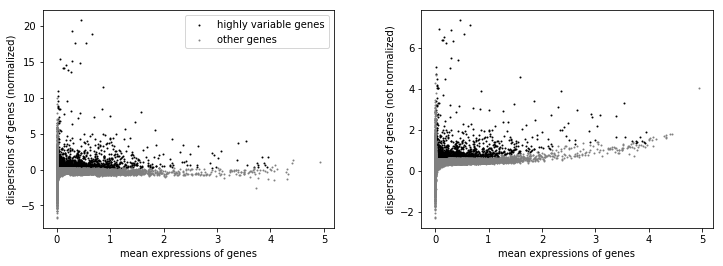

In [28]:
sc.pp.highly_variable_genes(adata_both, max_mean=4, min_disp=0.2)
sc.pl.highly_variable_genes(adata_both)
sc.pp.scale(adata_both)

In [29]:
np.sum(adata_both.var['highly_variable'])

3247

## Calculate PCA

In [30]:
sc.tl.pca(adata_both)
X_pca = adata_both.obsm['X_pca']

... storing 'CMP' as categorical
... storing 'CMP_broad' as categorical
... storing 'ESLAM' as categorical
... storing 'GMP' as categorical
... storing 'GMP_broad' as categorical
... storing 'HSC1' as categorical
... storing 'LMPP' as categorical
... storing 'LMPP_broad' as categorical
... storing 'LTHSC' as categorical
... storing 'LTHSC_broad' as categorical
... storing 'MEP' as categorical
... storing 'MEP_broad' as categorical
... storing 'MPP' as categorical
... storing 'MPP1' as categorical
... storing 'MPP1_broad' as categorical
... storing 'MPP2' as categorical
... storing 'MPP2_broad' as categorical
... storing 'MPP3' as categorical
... storing 'MPP3_broad' as categorical
... storing 'MPP_broad' as categorical
... storing 'Projected' as categorical
... storing 'STHSC' as categorical
... storing 'STHSC_broad' as categorical
... storing 'exp_groups' as categorical
... storing 'sample' as categorical


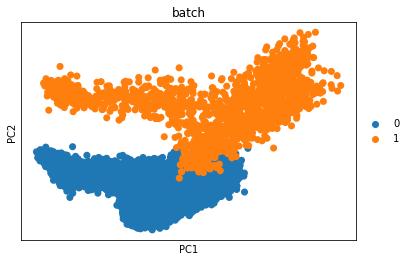

In [31]:
sc.pl.pca(adata_both, color='batch', size=200)

Perform MNN correction

In [33]:
pca_10x = sc.AnnData(X_pca[adata_both.obs['batch'] == '0'])
pca_nestorowa = sc.AnnData(X_pca[adata_both.obs['batch'] == '1'])
pca_corrected = sce.pp.mnn_correct(pca_10x, pca_nestorowa)

Performing cosine normalization...
Starting MNN correct iteration. Reference batch: 0
Step 1 of 1: processing batch 1
  Looking for MNNs...
  Computing correction vectors...
  Adjusting variance...
  Applying correction...
MNN correction complete. Gathering output...
Packing AnnData object...
Done.


In [34]:
pca_10x_corrected = pca_corrected[0][:adata_10x.n_obs].X
pca_nestorowa_corrected = pca_corrected[0][adata_10x.n_obs:].X

In [35]:
pca_10x_corrected.shape

(44802, 50)

In [36]:
pca_nestorowa_corrected.shape

(1654, 50)

In [37]:
adata_both_corrected = sc.AnnData(pca_corrected[0])
adata_both_corrected.obs_names = adata_both.obs_names
adata_both_corrected.obs['batch'] = adata_both.obs['batch']

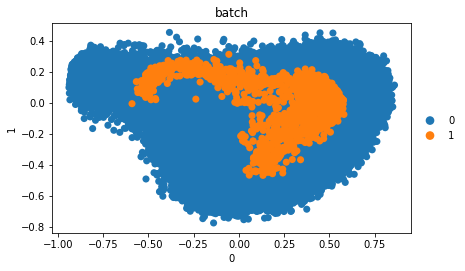

In [38]:
# Plot corrected PCA
sc.pl.scatter(adata_both_corrected, x='0', y='1', color='batch', size=200)

## Score neighbours

Calculate distances between Smart-seq2 and 10x data and identify k nearest neighbours of each cell

In [42]:
k = 15

cell_type_list = list(meta_nestorowa.columns)

for i, ct in enumerate(cell_type_list):
    
    print("Calculating neighbour scores for " + ct)

    nestorowa_ct_cells = np.where(adata_nestorowa.obs[ct])[0]
    n_ct = np.sum(adata_nestorowa.obs[ct])

    cell_distances_ct = cdist(pca_nestorowa_corrected[nestorowa_ct_cells, :], pca_10x_corrected, metric='euclidean')

    Adj = np.zeros(cell_distances_ct.shape, dtype=float)
    indices = np.zeros((cell_distances_ct.shape[0], k), dtype=np.int_)

    for irow, row in enumerate(cell_distances_ct):
        idcs = np.argpartition(row, k)[:k]
        indices[irow] = idcs

    for irow, row in enumerate(indices):
        Adj[irow, row] = 1

    adjacency_score = np.sum(Adj, axis=0)

    adata_10x.obs['adjacency_score_' + ct] = adjacency_score/n_ct*1000

Calculating neighbour scores for LTHSC_broad
Calculating neighbour scores for LMPP_broad
Calculating neighbour scores for MPP_broad
Calculating neighbour scores for CMP_broad
Calculating neighbour scores for MEP_broad
Calculating neighbour scores for GMP_broad
Calculating neighbour scores for MPP1_broad
Calculating neighbour scores for MPP2_broad
Calculating neighbour scores for MPP3_broad
Calculating neighbour scores for STHSC_broad
Calculating neighbour scores for LTHSC
Calculating neighbour scores for LMPP
Calculating neighbour scores for MPP
Calculating neighbour scores for CMP
Calculating neighbour scores for MEP
Calculating neighbour scores for GMP
Calculating neighbour scores for MPP1
Calculating neighbour scores for MPP2
Calculating neighbour scores for MPP3
Calculating neighbour scores for STHSC
Calculating neighbour scores for ESLAM
Calculating neighbour scores for HSC1
Calculating neighbour scores for Projected


## Plot

Load the co-ordinates from paper

In [43]:
coords_10x_file = '/home/fkh23/rds/rds-bg200-hphi-gottgens/users/fkh23/Niki_10x/SLX11508/Coordinates/wt_gephi_coordinates.csv'
coords_10x = pd.read_csv(coords_10x_file, index_col=0)
coords_10x = coords_10x.reindex(adata_10x.obs_names)
adata_10x.obsm['X_draw_graph_gephi'] = np.array(coords_10x)

In [44]:
color_map = LinearSegmentedColormap.from_list('ss2_to_10x', ['lightgrey', 'red', 'darkred'])

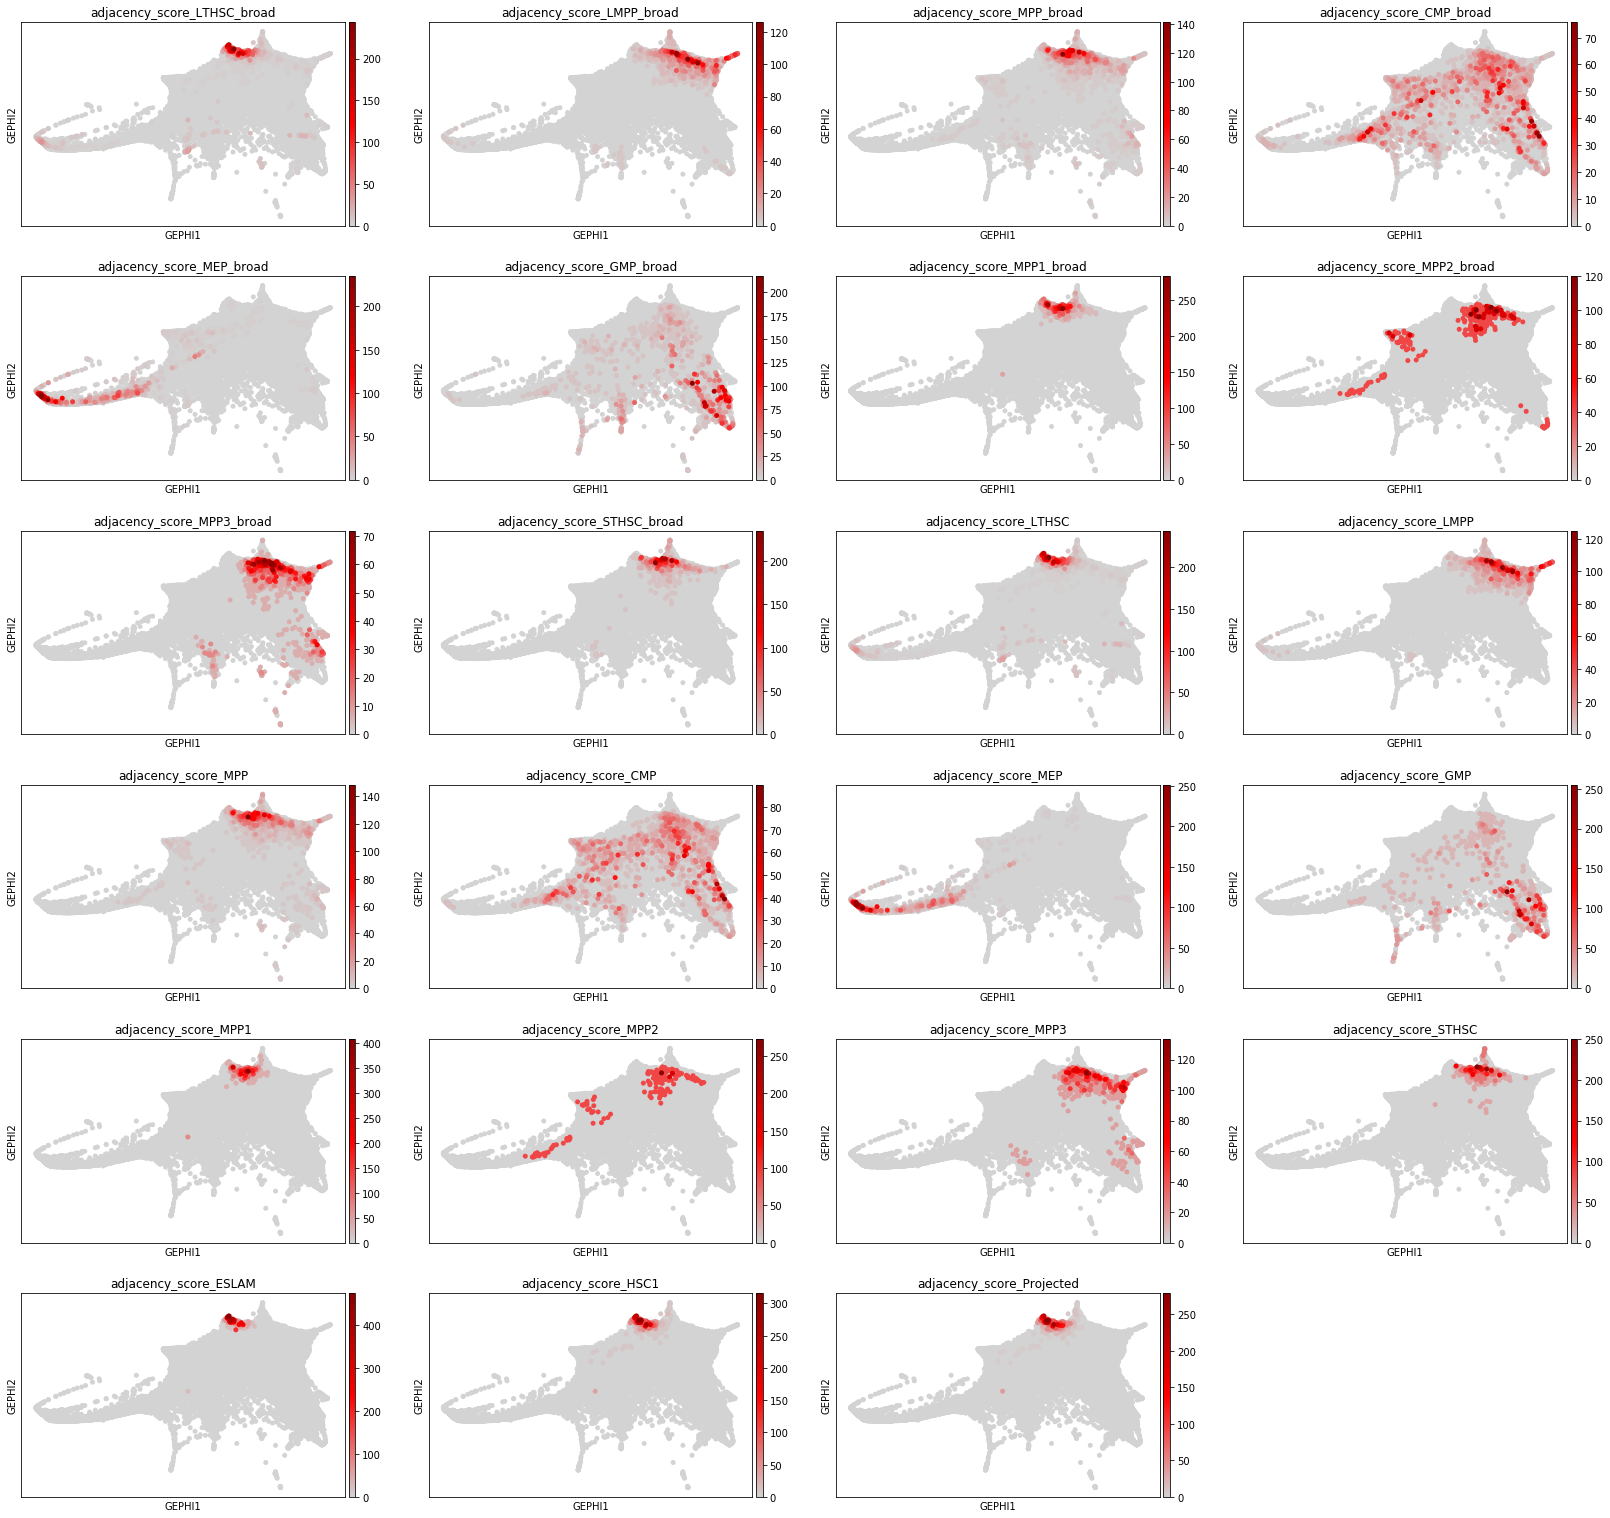

In [46]:
sc.pl.draw_graph(adata_10x, color=['adjacency_score_' + ct for ct in cell_type_list], size=100, layout='gephi',
                 color_map=color_map)